# SIM (UNIT) → FastPM Haloscope enrichment

Schema notebook (not executed in CI). Wires **UNIT** consistent-trees and **FastPM** Rockstar `out_8.list` at **scale factor a=1 (z=0)** through Haloscope (`density_field_properties.haloscope`).

**Inputs:** `config/fastpm_folders.md`, paths in `haloscope/sim_to_fastpm/config.py`.

**Outputs:** enriched Parquet under `output/sim_to_fastpm_haloscope/`, validation PDFs.

Relation to `density_field_properties`: same Rockstar `.list` as tidal pipelines; here `env` is a halo-halo KD-tree proxy, not the tidal tensor from the density field.

## 0. Python path

Run from repo root or set `REPO_ROOT` below. Requires `src` on `PYTHONPATH`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "density_field_properties").is_dir():
    REPO_ROOT = Path.cwd().parent

sys.path.insert(0, str(REPO_ROOT / "src"))

from density_field_properties.haloscope import ConditionalMultiVariateGaussian

## 1. Configuration

| Quantity | Value |
|----------|--------|
| UNIT SIM | `/data5/UNITSIM/fixedAmp_InvPhase_001/ROCKSTAR/outputs` → `hlists/hlist_1.00000.list.bz2` |
| FastPM | `/data21/users/mruiz/fastpm_MN5/fastpm_tfm/rockstar_out_pm/out_8.list` |
| Box (both) | 1000 Mpc/h (UNIT header + `default_params.L_BOX`) |
| Cosmology | Om=0.3089, Ol=0.6911, h=0.6774 in both catalogs |

Set `QUICK_RUN = True` in the config cell for subset limits (`SMOKE_*`); `False` uses `MAX_*_HALOS` (`None` = full catalogs).

In [34]:
from density_field_properties.haloscope.sim_to_fastpm import config
from density_field_properties.haloscope.sim_to_fastpm.config import (
    ENV_RADIUS_MPC_H,
    OUTPUT_DIR,
    ENRICHED_PARQUET_NAME,
    QUICK_RUN,
    default_fastpm_list_path,
    max_fastpm_halos_for_run,
    max_sim_halos_for_run,
    min_bin_size_for_run,
    default_sim_hlist_path,
)

config.QUICK_RUN = True  # subset run (SMOKE_* limits in config.py)
CALIBRATE_MASS = False

MAX_SIM_HALOS = max_sim_halos_for_run(config.QUICK_RUN)
MAX_FASTPM_HALOS = max_fastpm_halos_for_run(config.QUICK_RUN)
MIN_BIN_SIZE = min_bin_size_for_run(config.QUICK_RUN)

SIM_PATH = default_sim_hlist_path()
FASTPM_PATH = default_fastpm_list_path()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"QUICK_RUN={config.QUICK_RUN}  MAX_SIM={MAX_SIM_HALOS}  MAX_FASTPM={MAX_FASTPM_HALOS}")

QUICK_RUN=True  MAX_SIM=8000  MAX_FASTPM=8000


## 2. Load catalogs

In [3]:
from density_field_properties.haloscope.sim_to_fastpm.load_catalogs import (
    load_fastpm_target_catalog,
    load_unit_sim_training_catalog,
)

halos_sim = load_unit_sim_training_catalog(SIM_PATH, max_halos=MAX_SIM_HALOS)
halos_fastpm = load_fastpm_target_catalog(FASTPM_PATH, max_halos=MAX_FASTPM_HALOS)
print(f"UNIT hosts: {len(halos_sim)}")
print(f"FastPM halos: {len(halos_fastpm)}")

UNIT hosts: 7162
FastPM halos: 1981597


(array([1.19599881e-13, 8.10118143e-14, 4.58844485e-14, ...,
        0.00000000e+00, 0.00000000e+00, 2.05920532e-19], shape=(1407,)),
 array([1.80590000e+12, 4.25657100e+12, 6.70724200e+12, ...,
        3.44499866e+15, 3.44744933e+15, 3.44990000e+15], shape=(1408,)),
 <BarContainer object of 1407 artists>)

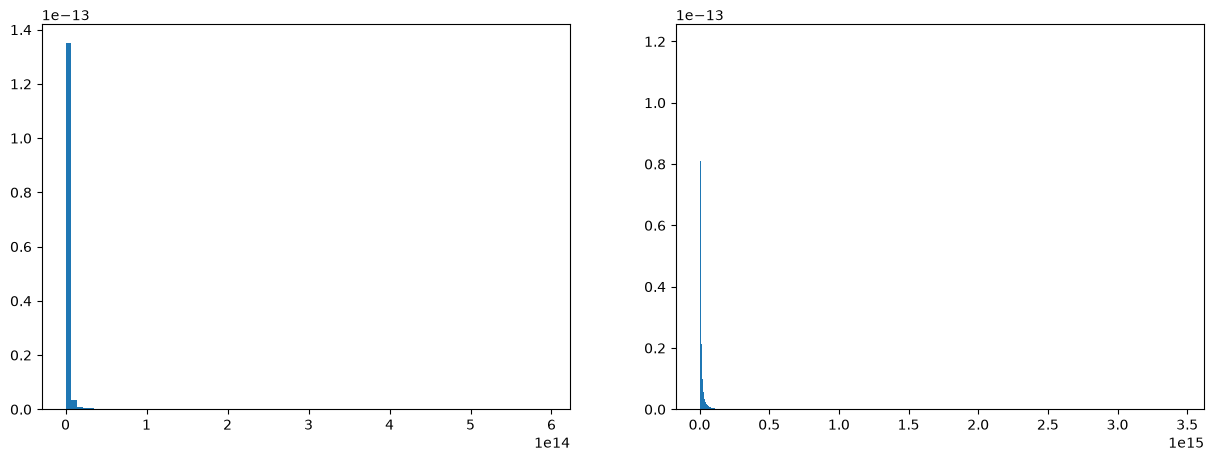

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(15,5))

axes[0].hist(halos_sim.M200b, density=True,bins=int(np.sqrt(len(halos_sim))))
axes[1].hist(halos_fastpm.M200b, density=True, bins=int(np.sqrt(len(halos_fastpm))))


## 3. Optional mass calibration (FastPM → SIM mass function)

In [35]:
from density_field_properties.haloscope.sim_to_fastpm.mass_matching import abundance_match_mass

if CALIBRATE_MASS:
    halos_fastpm["M200b_cal"] = abundance_match_mass(
        halos_fastpm["M200b"].to_numpy(), halos_sim["M200b"].to_numpy()
    )
    MASS_COL_FASTPM = "M200b_cal"
else:
    MASS_COL_FASTPM = "M200b"

## 4. Local environment feature `env` (identical algorithm, each box size)

In [36]:
from density_field_properties.haloscope.sim_to_fastpm.environment import local_environment
from density_field_properties.haloscope.sim_to_fastpm.config import FASTPM_BOXSIZE_MPC_H, SIM_BOXSIZE_MPC_H

halos_sim["env"] = local_environment(
    halos_sim[["x", "y", "z"]].to_numpy(),
    SIM_BOXSIZE_MPC_H,
    radius_mpc_h=ENV_RADIUS_MPC_H,
)
halos_fastpm["env"] = local_environment(
    halos_fastpm[["x", "y", "z"]].to_numpy(),
    FASTPM_BOXSIZE_MPC_H,
    radius_mpc_h=ENV_RADIUS_MPC_H,
)

## 5. Mass bins and SIM hold-out validation

In [37]:
import numpy as np
from density_field_properties.haloscope.sim_to_fastpm.training import default_mass_bin_edges, holdout_validate_sim_bins

BIN_EDGES = default_mass_bin_edges(np.log10(halos_sim["M200b"].max()))
val_results = holdout_validate_sim_bins(halos_sim, BIN_EDGES, min_bin_size=MIN_BIN_SIZE)

here
acceptance rate is  97.15536105032822 %
here
acceptance rate is  94.83282674772036 %
here
acceptance rate is  96.52173913043478 %


/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (444). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (471). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (471). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (111). n_quantiles is set to n_samples.
  warnings.wa

## 6. Train on full SIM and enrich FastPM

In [38]:
from density_field_properties.haloscope.sim_to_fastpm.training import enrich_fastpm_catalog

halos_fastpm_enriched, models = enrich_fastpm_catalog(
    halos_sim,
    halos_fastpm,
    BIN_EDGES,
    mass_column_fastpm=MASS_COL_FASTPM,
    min_bin_size=MIN_BIN_SIZE,
)
out_parquet = OUTPUT_DIR / ENRICHED_PARQUET_NAME
halos_fastpm_enriched.to_parquet(out_parquet, index=False)
print("saved:", out_parquet)

here
acceptance rate is  95.06514637091381 %
here
acceptance rate is  95.57607140334677 %
saved: output/sim_to_fastpm_haloscope/fastpm_out_8_haloscope_enriched.parquet


## 7. Diagnostics (corner plots + M–property medians)

In [39]:
import pandas as pd
from density_field_properties.haloscope.sim_to_fastpm.config import OUTPUT_FEATURES
from density_field_properties.haloscope.sim_to_fastpm.plotting import corner_plot_sim_validation, median_property_vs_mass
import matplotlib.pyplot as plt

for bin_index, y_true, y_pred in val_results:
    if y_true is None:
        continue
    df_true = pd.DataFrame(y_true, columns=OUTPUT_FEATURES)
    corner_plot_sim_validation(
        df_true,
        y_pred,
        f"SIM hold-out — mass bin {bin_index}",
        str(OUTPUT_DIR / f"val_sim_bin{bin_index}.pdf"),
    )

In [40]:
logM_fastpm = np.log10(halos_fastpm_enriched[MASS_COL_FASTPM].to_numpy())
for bin_index in range(len(BIN_EDGES) - 1):
    lo, hi = BIN_EDGES[bin_index], BIN_EDGES[bin_index + 1]
    sim_bin = halos_sim[(np.log10(halos_sim.M200b) >= lo) & (np.log10(halos_sim.M200b) < hi)]
    fp_mask = (logM_fastpm >= lo) & (logM_fastpm < hi)
    fp_bin = halos_fastpm_enriched.loc[fp_mask & halos_fastpm_enriched["cv"].notna()]
    if len(sim_bin) < 10 or len(fp_bin) < 10:
        continue
    corner_plot_sim_validation(
        sim_bin,
        fp_bin[list(OUTPUT_FEATURES)].to_numpy(),
        f"SIM vs FastPM generated — mass bin {bin_index}",
        str(OUTPUT_DIR / f"sim_vs_fastpm_bin{bin_index}.pdf"),
    )

## 8. Full-run notes

- Set `MAX_SIM_HALOS` / `MAX_FASTPM_HALOS` to `None` in `haloscope/sim_to_fastpm/config.py`.
- `out_8.list` is ~1 GB; KD-tree `env` and Haloscope fits are heavy — use an interactive node or Slurm with enough RAM.
- Confirm `out_8.list` is the intended redshift snapshot; change `FASTPM_LIST_NAME` if you need another `out_*.list`.
- Dependencies: `scikit-learn`, `pyarrow` (Parquet), package `density_field_properties` on `PYTHONPATH`.